###### Note: The most widely used and reliable general approach for solving ODEs is a family of methods known as Runge–Kutta methods. 

###### SciPy provides a routine for solving differential equations called scipy. integrate.odeint(), which uses variable step sizes and error-checking methods to produce accurate and efficient results. Call this function with a derivatives function, an initial state value (which may be an array), and an array of times, and it returns an array of state values corresponding to those times.

###### This example is taken from the book Computational Physics with python. Here, I slightly modified the code. A mass m is attached to a spring with spring constant k, which is attached to a support point. The length of the resulting pendulum at any given time is the spring rest length xo plus the stretch (or compression) x, and the angle of the pendulum with respect to the vertical is θ. This is an example of a coupled oscillator system: the “pendulum” oscillations in θ interact with the “spring” oscillations in x, producing a complex mix of both. The differential equations for this system are given below.θ a progrx


In [1]:
from IPython.display import display, Math, Markdown

display(Markdown("###### Radial equation"))
display(Math(r"\ddot{L} = (L_0 + L)\,\dot{\theta}^2 - \frac{k}{m}L + g\cos\theta"))

display(Markdown("###### Angular equation"))
display(Math(r"\ddot{\theta} = -\frac{1}{L_0 + L}\left(g\sin\theta + 2\dot{L}\,\dot{\theta}\right)"))

###### Radial equation

<IPython.core.display.Math object>

###### Angular equation

<IPython.core.display.Math object>

###### Write a program that plots the motion of the mass for some initial θ= 0.

In [2]:
from pylab import *
from scipy.integrate import odeint

N = 1000   # Number of steps

'''
We actually need to track four parameters here:
L, L̇, θ, and θ̇.

So, instead of using the usual N × 2 array, create an N × 4 array. Each row will contain the 
four-element state of the system at a specific instant in time, with consecutive rows separated by 
a time step dt. We will use the parameter order listed above.
'''

y = np. zeros ([4])
L_o = 1.0  # original spring length
L = 1.0   # Initial stretch of spring
v_o = 0.0  # # initial velocity
theta_o = 0.3  # radians
omega_o = 0.0  # initial angular velocity


y [0] = L  # set initial state
y [1] = v_o
y [2] = theta_o
y [3] = omega_o

time = linspace (0, 25, N)
k = float(input("Enter spring constant (for example 3.5):"))   #  spring constant , in N/m
m = float(input("Enter mass (for example 0.2):")) #  mass, in kg
gravity = 9.8 # g, in m/sˆ2

Enter spring constant (for example 3.5): 3.51
Enter mass (for example 0.2): 0.21


In [3]:
def spring_pendulum(y, t):
    g0 = y[1]
    g1 = (L_o+y[0])*y[3]*y[3] - k/m*y[0] + gravity*cos(y[2])
    g2 = y[3]
    g3 = -(gravity*sin(y[2]) + 2.0*y[1]*y[3])/(L_o + y[0])
    return array ([g0 , g1, g2, g3])

In [4]:
# Now we do the calculations.
result = odeint(spring_pendulum, y, time)
print("Spring_Pendulum:", spring_pendulum)
print("Initial state:", y)
print("time:", time[:20]) # first 10 data

Spring_Pendulum: <function spring_pendulum at 0x000001FF18A80EA0>
Initial state: [1.  0.  0.3 0. ]
time: [0.         0.02502503 0.05005005 0.07507508 0.1001001  0.12512513
 0.15015015 0.17517518 0.2002002  0.22522523 0.25025025 0.27527528
 0.3003003  0.32532533 0.35035035 0.37537538 0.4004004  0.42542543
 0.45045045 0.47547548]


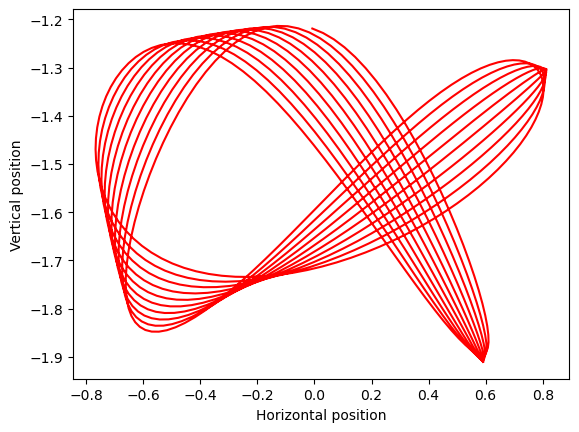

In [5]:
xdata = (L_o + result[:, 0]) * sin(result[:, 2])
ydata = -(L_o + result[:, 0]) * cos(result[:, 2])

plot(xdata, ydata, 'r-')
xlabel("Horizontal position")
ylabel("Vertical position")
show()